# 4. Experimental Design & Linear Modeling in R

This workbook teaches how experimental choices—such as **sample size ($n$)**, **noise (SD)**, **confounding variables**, and **replicate structure**—change statistical outputs in R.

### How to use this workbook:
1. Run each cell sequentially using **Shift + Enter**.
2. Locate the **"TRY THIS"** section in each exercise.
3. Change the specified variables, re-run the cell, and observe how the statistical summary output changes.

> **Terms**
>
> - **Linear model** — an equation of the form *outcome = baseline + effects + noise*. The t-test,
>   ANOVA and linear regression are all special cases of it, and `lm()` fits all of them.
> - **Coefficient (Estimate)** — the model's estimate of one effect: a slope, or the difference
>   between a group and the reference group.
> - **Standard error** — how uncertain that estimate is. The p-value is computed from the estimate
>   divided by its standard error.
> - **Biological replicate** — an independent unit (a different mouse). **Technical replicate** — a
>   repeat measurement of the same unit.
> - **Covariate** — another variable that affects the outcome. **Confounder** — a covariate that is
>   *also* linked to the treatment, so that its effect can be mistaken for the treatment's.
> - **Batch effect** — a technical shift shared by all samples processed together.

## Exercise 0: Continuous Linear Regression (`lm` Basics)

We evaluate a continuous relationship: How does gene expression change with increasing **drug dose**?

$$\text{Expression} = \text{Baseline} + (\text{Slope} \times \text{Dose}) + \text{Noise}$$

--- **TRY THIS** ---
1. **Change `noise_sd` from `1.5` to `5.0`:** What happens to the `Std. Error` and the `Pr(>|t|)` p-value?
2. **Change `true_slope` from `1.2` to `0.1`:** How close is the fitted `dose` estimate to the true value when the effect is very weak?

=== REGRESSION COEFFICIENTS ===


            Estimate Std. Error   t value     Pr(>|t|)
(Intercept) 4.315087 0.65684513  6.569414 1.055621e-06
dose        1.251196 0.09886667 12.655392 7.592398e-12


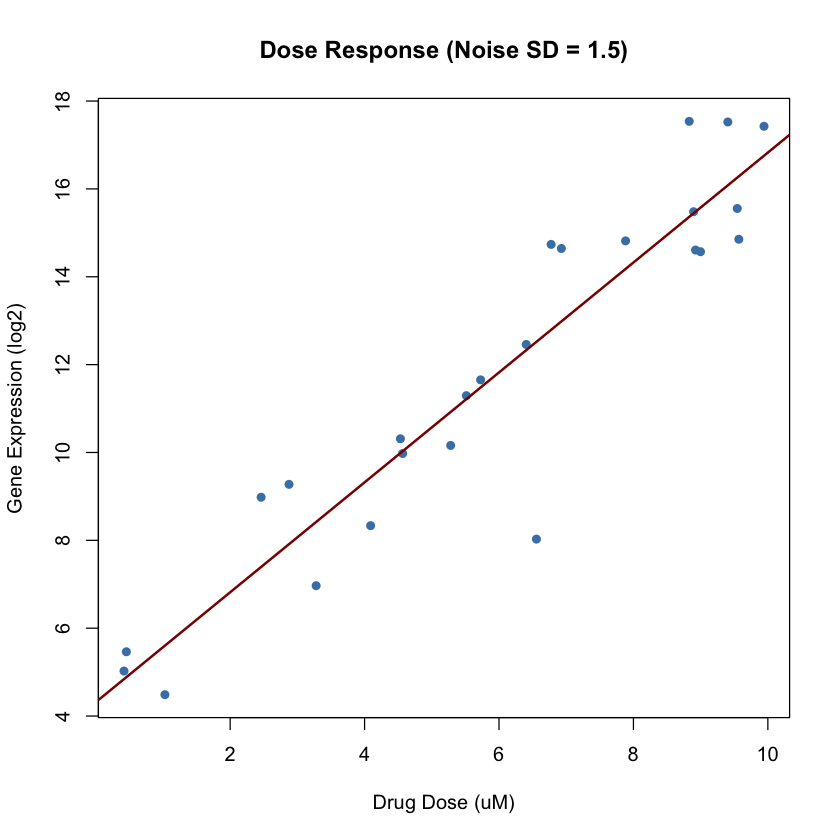

In [1]:
rm(list = ls())
set.seed(123)

# --- VARIABLES YOU CAN CHANGE --- 
n_samples  <- 25     # Sample size (Number of observations)
true_slope <- 1.2    # True increase in gene expression per 1 uM of drug
noise_sd   <- 1.5    # Technical / Biological background noise
# ---------------------------------

# Doses spread at random between 0 and 10 uM
dose <- runif(n_samples, min = 0, max = 10)
# Expression = baseline 5.0 + slope x dose + random noise (the equation above)
expr_dose <- 5.0 + (true_slope * dose) + rnorm(n_samples, mean = 0, sd = noise_sd)

# Fit linear model — read "~" as "explained by"
fit_dose <- lm(expr_dose ~ dose)

# Plot data and regression line
plot(dose, expr_dose, pch = 16, col = "steelblue",
     xlab = "Drug Dose (uM)", ylab = "Gene Expression (log2)",
     main = paste0("Dose Response (Noise SD = ", noise_sd, ")"))
abline(fit_dose, col = "darkred", lwd = 2)

# Print statistical summary table
cat("=== REGRESSION COEFFICIENTS ===\n")
print(summary(fit_dose)$coefficients)

### What to look for in the output table:
- **`(Intercept) Estimate`**: Predicted gene expression at `dose = 0`.
- **`dose Estimate`**: The fitted slope (should be close to `true_slope`).
- **`Std. Error`**: The uncertainty in your slope. **Higher noise ($SD$) increases standard error.**
- **`Pr(>|t|)`**: The p-value. If $p < 0.05$, the effect of dose is statistically significant.

## Exercise 1: Sample Planning ($n$) & Pseudoreplication

- **Biological Replicates ($n$):** Independent biological units (different mice).
- **Technical Replicates:** Measuring the exact same biological sample multiple times (e.g., 4 qPCR wells from 1 mouse).

--- **TRY THIS** ---
1. Run the cell as-is. The simulation includes a real treatment effect of 1.0. Notice how the **INCORRECT** model (treating 4 technical reps per mouse as independent) gives a much smaller standard error and p-value than the **CORRECT** model: it is far more confident than 2 mice per group can justify.
2. **Change `tech_reps` from `4` to `20`:** Observe how the **INCORRECT** model gets even more artificially overconfident ($p \rightarrow 0$), while the **CORRECT** model accurately reflects that $n = 2$ biological mice per group is not enough.

In [2]:
set.seed(10)

# --- VARIABLES YOU CAN CHANGE --- 
n_mice_per_group <- 2  # True biological sample size (n per group)
tech_reps        <- 4  # Technical measurements per mouse
# ---------------------------------

mouse_id    <- factor(paste0("Mouse", 1:(2 * n_mice_per_group)))
mouse_group <- factor(rep(c("control", "treated"), each = n_mice_per_group))

# Dataframe with repeated measurements: each mouse appears tech_reps times
tech_df <- data.frame(
  mouse = rep(mouse_id, each = tech_reps),
  group = rep(mouse_group, each = tech_reps)
)

# Biological variation between individual mice
mouse_baselines <- rnorm(2 * n_mice_per_group, mean = 8.0, sd = 0.5)
names(mouse_baselines) <- levels(mouse_id)

# Generate expression with minor technical machine noise (sd = 0.08)
# Each measurement = its mouse's baseline + 1.0 if treated + a little assay noise.
# So all measurements from one mouse share the same baseline: they are not independent.
tech_df$expr <- mouse_baselines[tech_df$mouse] + 
                1.0 * (tech_df$group == "treated") + 
                rnorm(nrow(tech_df), mean = 0, sd = 0.08)

# INCORRECT MODEL: Treats technical replicates as independent mice
fit_wrong <- lm(expr ~ group, data = tech_df)
cat("=== INCORRECT (Pseudoreplication: Assuming n =", nrow(tech_df)/2, "per group) ===\n")
print(summary(fit_wrong)$coefficients)

# CORRECT MODEL: Averages technical replicates per mouse first
# aggregate() collapses the rows to one mean per mouse, so each mouse counts once
clean_df <- aggregate(expr ~ mouse + group, data = tech_df, FUN = mean)
fit_correct <- lm(expr ~ group, data = clean_df)
cat("\n=== CORRECT (Averaged by mouse: True n =", n_mice_per_group, "per group) ===\n")
print(summary(fit_correct)$coefficients)

=== INCORRECT (Pseudoreplication: Assuming n = 8 per group) ===


              Estimate Std. Error    t value     Pr(>|t|)
(Intercept)  7.9494934 0.05438441 146.172280 1.081550e-23
grouptreated 0.5762656 0.07691117   7.492612 2.911323e-06



=== CORRECT (Averaged by mouse: True n = 2 per group) ===


              Estimate Std. Error   t value     Pr(>|t|)
(Intercept)  7.9494934  0.1305990 60.869488 0.0002697894
grouptreated 0.5762656  0.1846949  3.120096 0.0891928817


**Question 4.1** In this simulation the treatment effect is 1.0 and mice differ with a standard
deviation of 0.5. How many mice per group would you need for 80% power? Use
`power.t.test(delta = 1.0, sd = 0.5, power = 0.8)`. Does adding technical replicates change that
number?

## Exercise 2: Controlling for Covariates (`litter_size` & `strain`)

Here we study a complete experiment with $n = 15$ biological samples per condition across two strains (`C57BL6` vs `BALBc`) while controlling for `litter_size` (continuous covariate).

In this simulation, strain and litter size are assigned independently of treatment: both strains appear equally in both groups, and litter size is random. They affect expression but are not linked to treatment, so they are **covariates, not confounders**. Including them in the model does not change the estimated drug effect much, but it removes variation from the residuals and makes the estimate more precise.

--- **TRY THIS** ---
1. **Change `litter_effect` from `-0.35` to `0.0`:** What happens to the continuous scatter plot on the right?
2. **Change `true_drug_effect` from `2.0` to `0.0` (no drug effect):** Look at the beeswarm plot. Does the vertical gap between `control` and `treated` disappear?
3. **Change `strain_effect` from `1.5` to `4.0`:** Look at how the `strainBALBc` coefficient in the summary table changes.

=== MULTI-VARIABLE MODEL COEFFICIENTS ===


               Estimate Std. Error   t value     Pr(>|t|)
(Intercept)  11.5419703 0.42679204 27.043546 7.904417e-34
grouptreated  2.1957124 0.22772998  9.641736 1.686363e-13
strainBALBc   1.4759412 0.22731953  6.492804 2.374186e-08
litter_size  -0.3067998 0.05917782 -5.184372 3.083194e-06


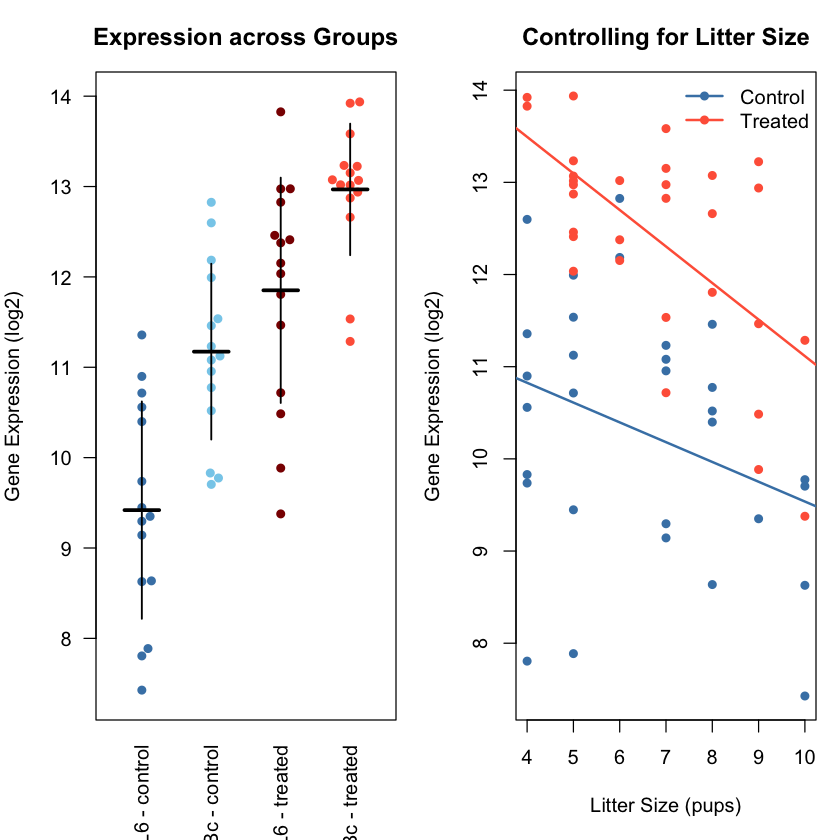

In [3]:
if (!requireNamespace("beeswarm", quietly = TRUE)) install.packages("beeswarm")
library(beeswarm)

set.seed(42)

# --- VARIABLES YOU CAN CHANGE --- 
n_per_comb       <- 15     # Biological replicates per strain/treatment group
true_drug_effect <- 2.0    # Drug effect size (+2.0 log2 fold change)
strain_effect    <- 1.5    # Baseline difference between BALBc and C57BL6
litter_effect    <- -0.35  # Expression drop per additional pup in litter
# ---------------------------------

# Balanced design: 60 mice, 30 per treatment, each treatment split 15/15 between strains
group <- factor(rep(c("control", "treated"), each = 2 * n_per_comb))
# C57BL6 is set as the reference level, so the model reports the BALBc difference (strainBALBc)
strain <- factor(rep(rep(c("C57BL6", "BALBc"), each = n_per_comb), times = 2), levels = c("C57BL6", "BALBc"))
litter_size <- sample(4:10, 4 * n_per_comb, replace = TRUE)   # random, so unrelated to treatment

# Generate expression
expr <- 12.0 + 
        true_drug_effect * (group == "treated") + 
        strain_effect * (strain == "BALBc") + 
        litter_effect * litter_size + 
        rnorm(4 * n_per_comb, sd = 0.8)

df_rich <- data.frame(group, strain, litter_size, expr)
# One label per strain/treatment combination, for plotting four groups side by side
df_rich$condition <- interaction(df_rich$strain, df_rich$group, sep = " - ")

# --- VISUALIZATION ---
par(mfrow = c(1, 2), mar = c(5, 4, 3, 1))

# Plot 1: Beeswarm with Mean & SD Bars
beeswarm(expr ~ condition, data = df_rich, pch = 16, 
         col = c("steelblue", "skyblue", "darkred", "tomato"),
         ylab = "Gene Expression (log2)", xlab = "", las = 2,
         main = "Expression across Groups")
# tapply() computes one mean (and SD) per combination, in the same order as the plot
means <- tapply(df_rich$expr, df_rich$condition, mean)
sds   <- tapply(df_rich$expr, df_rich$condition, sd)
segments(1:4 - 0.25, means, 1:4 + 0.25, means, lwd = 3, col = "black")
segments(1:4, means - sds, 1:4, means + sds, lwd = 1.5, col = "black")

# Plot 2: Scatter Plot with Regression Lines per Group
plot(df_rich$litter_size, df_rich$expr, pch = 16,
     col = ifelse(df_rich$group == "treated", "tomato", "steelblue"),
     xlab = "Litter Size (pups)", ylab = "Gene Expression (log2)",
     main = "Controlling for Litter Size")
fit_ctrl <- lm(expr ~ litter_size, data = df_rich[df_rich$group == "control", ])
fit_trt  <- lm(expr ~ litter_size, data = df_rich[df_rich$group == "treated", ])
abline(fit_ctrl, col = "steelblue", lwd = 2)
abline(fit_trt, col = "tomato", lwd = 2)
legend("topright", legend = c("Control", "Treated"), 
       col = c("steelblue", "tomato"), pch = 16, lwd = 2, bty = "n")

par(mfrow = c(1, 1))

# Full Linear Model Output
# One model with all three variables. Each coefficient is that variable's effect
# with the other two held constant. grouptreated is the drug effect.
fit_full <- lm(expr ~ group + strain + litter_size, data = df_rich)
cat("=== MULTI-VARIABLE MODEL COEFFICIENTS ===\n")
print(summary(fit_full)$coefficients)

**Question 4.2** Suppose instead that every treated mouse were `BALBc` and every control mouse
`C57BL6`. Strain would then be a confounder. Could any model separate the drug effect from the strain
effect? What would you change in the experimental design to avoid this?

## Exercise 3 (Optional): Batch Correction with `ComBat`

When an experiment is **balanced** (both control and treated samples exist across batches), but batch variation is strong, empirical Bayes methods like `ComBat` (from the `sva` package) can adjust the data matrix prior to model fitting.

ComBat estimates each batch effect by pooling information across many genes, so it needs a matrix of genes, not a single gene. The cell simulates 100 genes that all share the batch shift; `Gene 1` also carries the drug effect. Installing `sva` in Colab takes several minutes.

--- **TRY THIS** ---
1. **Change `batch_shift` from `4.0` to `8.0`:** Compare the models before and after ComBat. Observe how `ComBat` strips away the technical batch jump while preserving the true drug effect.

In [4]:
if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
if (!requireNamespace("sva", quietly = TRUE)) BiocManager::install("sva", update = FALSE, ask = FALSE)
library(sva)

set.seed(42)
n_batch <- 8

# --- VARIABLES YOU CAN CHANGE --- 
batch_shift <- 4.0  # Technical offset added by Batch 2
# ---------------------------------

# Balanced setup: 4 controls and 4 treated in Batch 1; 4 controls and 4 treated in Batch 2
group_bal <- factor(rep(c("control", "treated", "control", "treated"), each = n_batch / 2))
batch_bal <- factor(rep(c("Batch1", "Batch2"), each = n_batch))

# True effect = 1.5
expr_bal <- 5.0 + 1.5 * (group_bal == "treated") + batch_shift * (batch_bal == "Batch2") + rnorm(2 * n_batch, sd = 0.5)

# ComBat requires a matrix (genes in rows, samples in columns), and it estimates the
# batch effect by pooling across genes. So: 100 genes that all get the same batch shift,
# with our gene (expr_bal, which also has the drug effect) as row 1.
n_genes_cb <- 100
dat_matrix <- matrix(rnorm(n_genes_cb * 2 * n_batch, mean = 5.0, sd = 0.5), nrow = n_genes_cb)
dat_matrix <- dat_matrix + batch_shift * matrix(batch_bal == "Batch2", nrow = n_genes_cb,
                                                 ncol = 2 * n_batch, byrow = TRUE)
dat_matrix[1, ] <- expr_bal
# mod tells ComBat which variation is biological, so it does not remove the drug effect
mod_matrix <- model.matrix(~ group_bal)

# Before correction, for comparison
fit_raw <- lm(dat_matrix[1, ] ~ group_bal)
cat("=== LINEAR MODEL BEFORE COMBAT (gene 1) ===\n")
print(summary(fit_raw)$coefficients)

# Run ComBat
combat_expr <- ComBat(dat = dat_matrix, batch = batch_bal, mod = mod_matrix)

# Fit linear model on ComBat-cleaned data
fit_combat <- lm(combat_expr[1, ] ~ group_bal)
cat("\n=== LINEAR MODEL AFTER COMBAT ADJUSTMENT (gene 1) ===\n")
print(summary(fit_combat)$coefficients)

Loading required package: mgcv



Loading required package: nlme



This is mgcv 1.9-4. For overview type '?mgcv'.



Loading required package: genefilter



Loading required package: BiocParallel



...

Fitting L/S model and finding priors



Finding parametric adjustments



Adjusting the Data





=== LINEAR MODEL AFTER COMBAT ADJUSTMENT (gene 1) ===


                 Estimate Std. Error   t value     Pr(>|t|)
(Intercept)      7.452738  0.1543878 48.272847 5.689982e-17
group_baltreated 1.087980  0.2183373  4.983026 2.007391e-04


**Question 4.3** Before and after ComBat, compare the `group_baltreated` estimate and its standard
error. Which of the two did the batch effect mainly affect? Now imagine all treated samples had been
processed in Batch 2 and all controls in Batch 1. Could ComBat, or any other method, still separate
the batch effect from the drug effect?

## Exercise 4 (Optional): Differential Expression with `limma`

In high-throughput genomics (RNA-seq / microarrays), linear models are fitted across thousands of genes simultaneously using **`limma`** (`lmFit` and `eBayes`).

This cell reuses `df_rich` from Exercise 2, so run Exercise 2 first.

--- **TRY THIS** ---
1. Run the cell to analyze a matrix of 50 simulated genes.
2. Look at **`Gene_1`** in the `topTable` output: Notice how its `logFC` matches the `grouptreated Estimate` from Exercise 2.

In [5]:
# Install limma from Bioconductor if needed
if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
if (!requireNamespace("limma", quietly = TRUE)) BiocManager::install("limma", update = FALSE, ask = FALSE)
library(limma)

# Create simulated gene expression matrix (50 genes x 60 samples)
# 49 genes of pure noise: no drug, strain or litter effect
n_genes <- 50
expr_matrix <- matrix(rnorm(n_genes * nrow(df_rich), mean = 10, sd = 1), nrow = n_genes)
rownames(expr_matrix) <- paste0("Gene_", 1:n_genes)
colnames(expr_matrix) <- paste0("Sample_", 1:nrow(df_rich))

# Insert our true gene expression signal into Gene_1
expr_matrix[1, ] <- df_rich$expr

# 1. Build Design Matrix — the same model as in Exercise 2, written as a matrix
design <- model.matrix(~ group + strain + litter_size, data = df_rich)

# 2. Fit linear models across all 50 genes using lmFit() — one lm() per gene, in one call
fit_limma <- lmFit(expr_matrix, design)

# 3. Empirical Bayes Moderation — each gene's variance is pulled towards the average
#    across all genes, which stabilises the estimates when there are few samples
fit_bayes <- eBayes(fit_limma)

# 4. View Top Results for Drug Treatment
cat("=== TOP 5 DIFFERENTIALLY EXPRESSED GENES (LIMMA) ===\n")
topTable(fit_bayes, coef = "grouptreated", number = 5)

=== TOP 5 DIFFERENTIALLY EXPRESSED GENES (LIMMA) ===


,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Gene_1,2.1957124,11.352918,8.392738,7.434133e-17,3.717067e-15,27.875342
Gene_5,-0.8103378,9.963517,-3.097379,1.971753e-03,4.929382e-02,-2.350267
Gene_24,-0.5759570,10.047077,-2.201498,2.778209e-02,4.437343e-01,-4.708514
Gene_41,-0.5503557,10.099831,-2.103641,3.549874e-02,4.437343e-01,-4.917797
Gene_2,0.5135622,10.061263,1.963004,4.974452e-02,4.974452e-01,-5.201910


### Reading `limma` Output (`topTable`):
- **`logFC`**: Estimated drug effect size ($\log_2$ fold change).
- **`AveExpr`**: Average log2 expression across all samples.
- **`t`**: Moderated t-statistic.
- **`P.Value`**: Raw p-value.
- **`adj.P.Val`**: False Discovery Rate (FDR) adjusted p-value for multi-gene testing.

**Question 4.4** `Gene_1`'s `logFC` is identical to the `grouptreated` estimate from Exercise 2,
but its t-statistic is not. Why? Which part of the calculation does `eBayes()` change?